In [1]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wntr
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.simulation import Simulation
from pipedream_solver.nutils import interpolate_sample
import pipedream_utility as pdu
from pipedream_utility import *
import pipedream_simulation as pd_sim
from pipedream_simulation import run_pipedream_simulation
import viswaternet as vis
import math
import time

#Don't show future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

dt = 1800
t_run = 24
# import INP file

inp = 'C-Town.inp'
wn = wntr.network.WaterNetworkModel(inp)
# run hydraulic simulation using pipedream
t1 = time.time()
H_df_model, Q_df_model, Q_o_model, Q_pump_model, Q_prv_model, model, Q_in_all_df, pumps, superjunctions, orifices, superlinks, prvs, flip_mult_model = run_pipedream_simulation(inp, t_run = t_run, dt = dt, banded = False)
t2 = time.time()

print('Pipedream RUN:' +str(t2-t1)+ ' seconds')

'Simulation progress: pattern step 23, t = 23.50 h (84600 s)'

Pipedream RUN:69.33267545700073 seconds


In [2]:
from pipedream_simulation_sensor_results import run_pipedream_simulation_sensor

t1 = time.time()
H_df_groundtruth, Q_df_groundtruth, H_df_sensor, Q_df_sensor, Q_o_sensor, Q_pump_sensor, Q_prv_sensor, model, Q_in_all_df, pumps, superjunctions, orifices, superlinks, prvs, flip_mult_sensor = run_pipedream_simulation_sensor(inp, t_run = t_run, dt = dt, banded = False)
t2 = time.time()
print('Pipedream RUN:' +str(t2-t1)+ ' seconds')

'Simulation progress: pattern step 23, t = 23.50 h (84600 s)'

Pipedream RUN:72.8624484539032 seconds


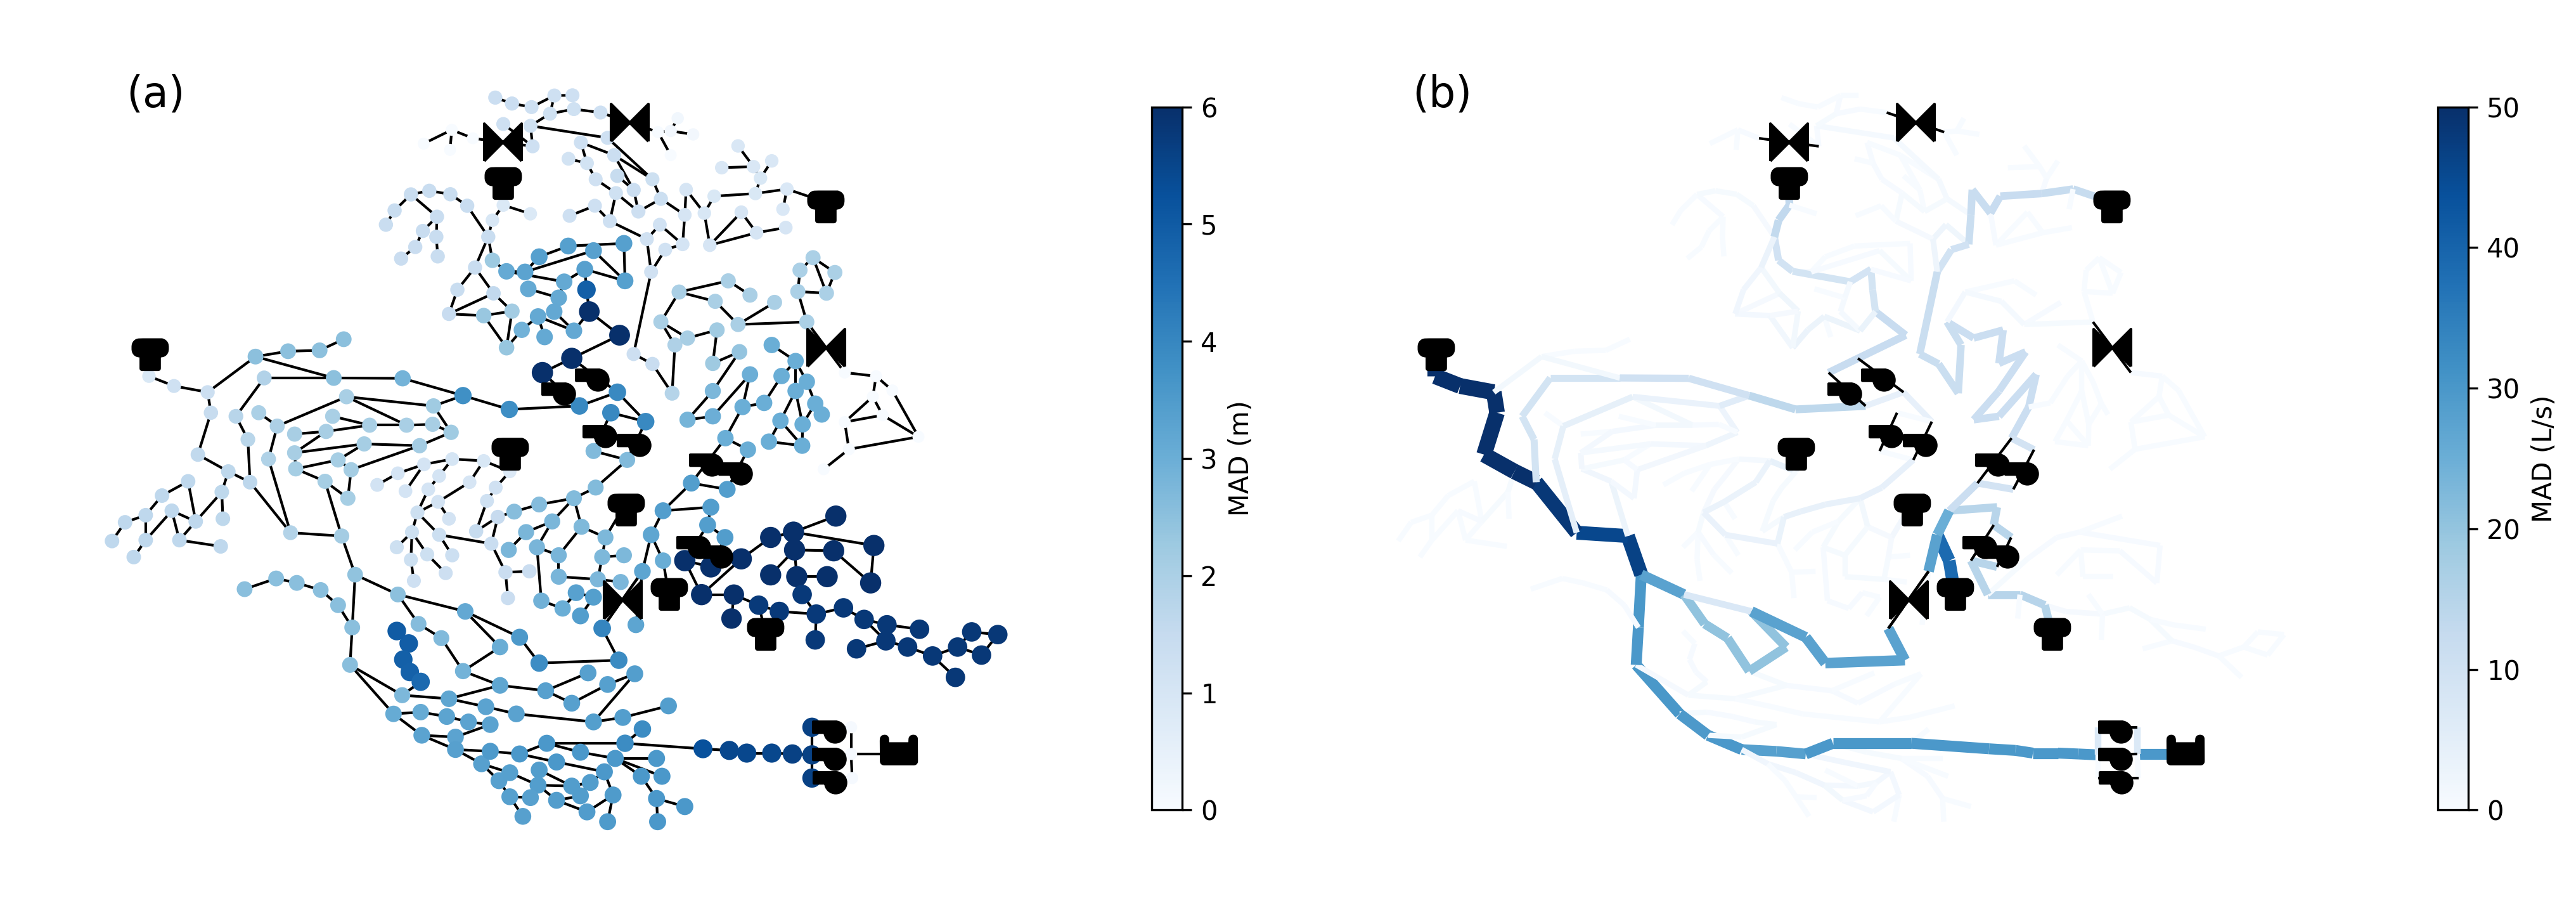

In [3]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

Q_df_model_lps = Q_df_model * 1000
Q_df_groundtruth_lps = Q_df_groundtruth * 1000
vis_model = vis.VisWNModel('CTOWN_map.inp')
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
head_err = np.abs(H_df_model - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_err = np.abs(Q_df_model_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]

head_max_limit = 6
flow_max_limit = 50

cmap = 'Blues'
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = (2,6), draw_color_bar = True,  
                                   node_size = (50,200), tank_color='k', draw_base_legend=False, color_bar_width = 0.01)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False) 
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node', 
                                   custom_data_values = [junction_names, head_err], data_type = 'continuous', 
                                    vmin = 0, vmax=head_max_limit, style = style, color_bar_title ='MAD (m)')

ax[1].set_frame_on(False) 
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction",  fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link', 
                           custom_data_values = [link_names, flow_err], data_type = 'continuous', 
                           vmin = 0, vmax = flow_max_limit, style = style, color_bar_title ='MAD (L/s)')

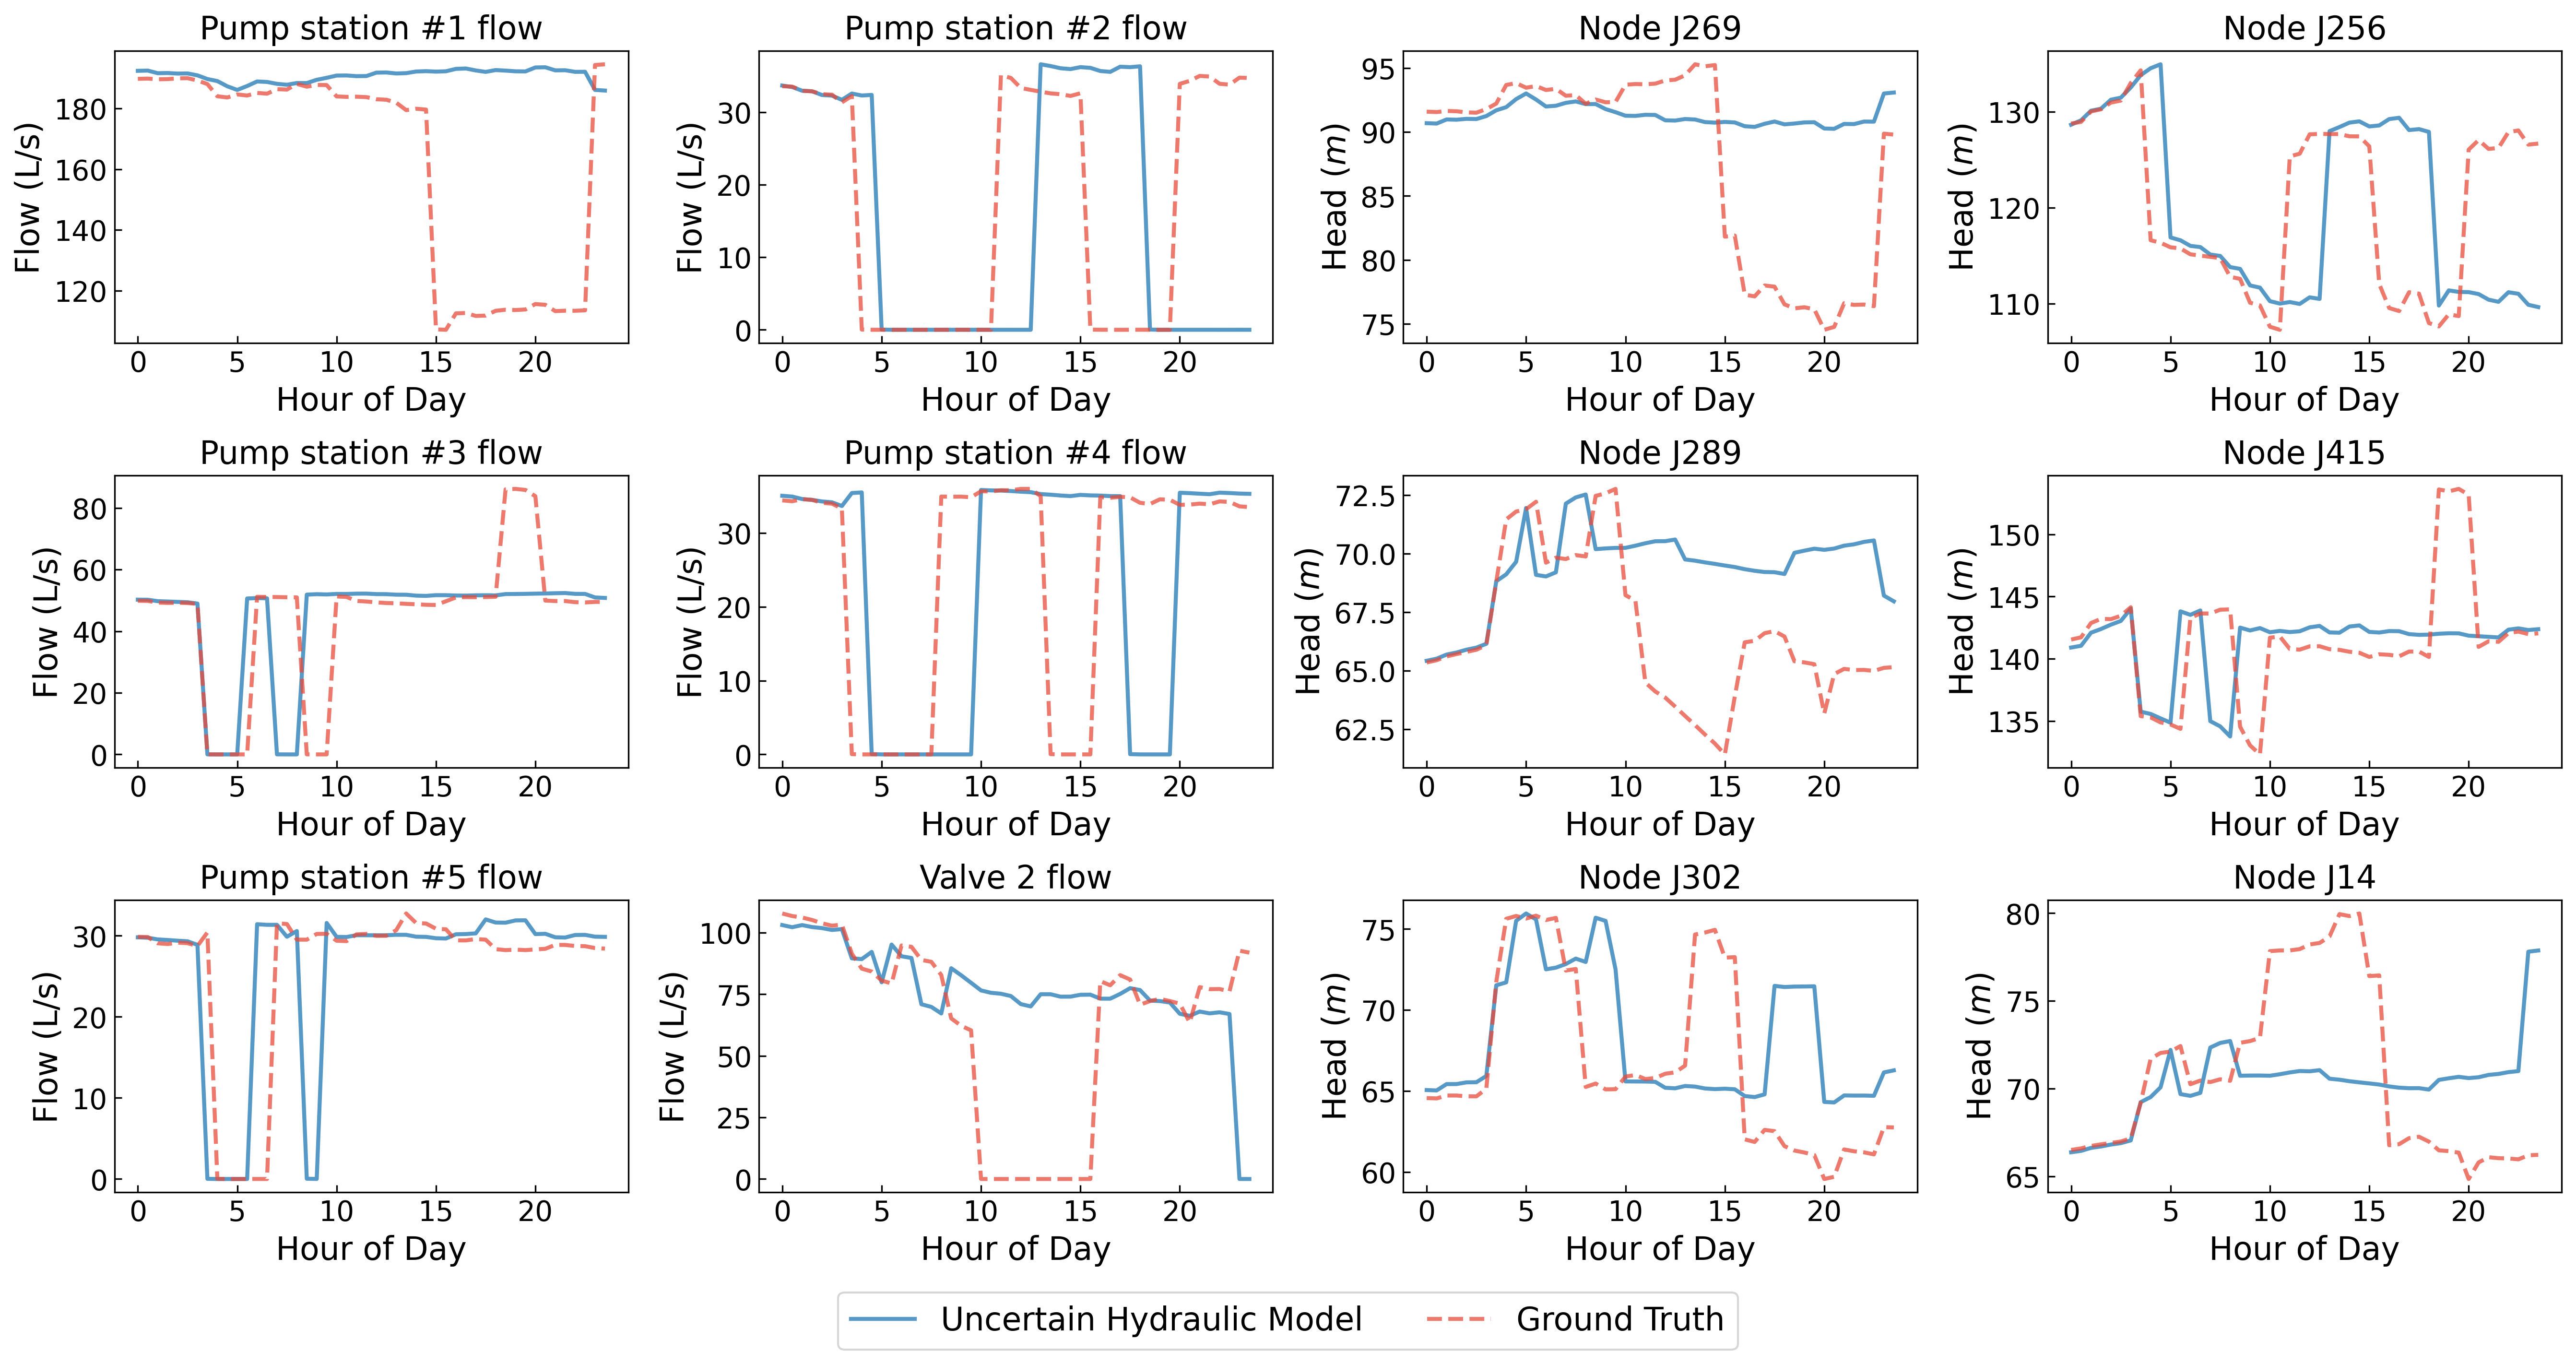

In [4]:
model_color = '#1f77b4'  
truth_color = '#e74c3c'  

n_cols = 4 
n_rows = 3

start_ind_wn = 0
junction_names = ['J269', 'J256', 'J289', 'J415', 'J302', 'J14']
link_names = ['P310', 'P796', 'P237', 'P409', 'P424', 'P467']

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, 9), dpi=300)

flow_titles = ['Pump station #1 flow','Pump station #2 flow','Pump station #3 flow','Pump station #4 flow','Pump station #5 flow','Valve 2 flow']
#head_titles = []

for i in range(len(junction_names)):  
    row = i // 2  
    col_flow = (i % 2)  
    col_head = col_flow + 2  


    # Flow
    ax[row, col_flow].plot(Q_df_model_lps.index[start_ind_wn:] / 3600, Q_df_model_lps[link_names[i]][start_ind_wn:], 
                           c=model_color, linewidth=2.0, alpha=0.75, label='Uncertain Hydraulic Model')
    ax[row, col_flow].plot(Q_df_groundtruth_lps.index[start_ind_wn:] / 3600, Q_df_groundtruth_lps[link_names[i]][start_ind_wn:], 
                           c=truth_color, linewidth=2.0, linestyle='--', alpha=0.75, label='Ground Truth')
    ax[row, col_flow].tick_params(axis='both', which='major', labelsize=14, labelcolor='black', direction='in')
    ax[row, col_flow].set_title(flow_titles[i], fontsize=16)
    ax[row, col_flow].set_ylabel('Flow (L/s)', fontsize=16)
    ax[row, col_flow].set_xlabel('Hour of Day', fontsize=16)


    # Head
    ax[row, col_head].plot(H_df_model.index[start_ind_wn:] / 3600, H_df_model[junction_names[i]][start_ind_wn:], 
                           c=model_color, linewidth=2.0, alpha=0.75, label='Uncertain Hydraulic Model')
    ax[row, col_head].plot(H_df_groundtruth.index[start_ind_wn:] / 3600, H_df_groundtruth[junction_names[i]][start_ind_wn:], 
                           c=truth_color, linewidth=2.0, linestyle='--', alpha=0.75, label='Ground Truth')
    ax[row, col_head].tick_params(axis='both', which='major', labelsize=14, labelcolor='black', direction='in')
    ax[row, col_head].set_title(f'Node {junction_names[i]}', fontsize=16)
    ax[row, col_head].set_ylabel('Head ($m$)', fontsize=16)
    ax[row, col_head].set_xlabel('Hour of Day', fontsize=16)

fig.legend(
    labels=['Uncertain Hydraulic Model', 'Ground Truth'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06), 
    ncol=2,
    fontsize=16,
    frameon=True
)
plt.tight_layout()
plt.show()